In [ ]:
# DAY 13 - CELL 1
# Load libraries and automatically find the dataset

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = None

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for folder in dirs:
        if folder == "Underwater-Image-Data-set-main":
            BASE_PATH = os.path.join(root, folder)
            break
    if BASE_PATH:
        break

print("Dataset path:", BASE_PATH)
print("Path exists:", os.path.exists(BASE_PATH))

Mounted at /content/drive
Dataset path: /content/drive/MyDrive/Underwater-Image-Data-set-main
Path exists: True


In [ ]:
# DAY 13 - CELL 2
# Collect complete Input-Target pairs

pairs = []

for root, dirs, files in os.walk(BASE_PATH):
    for file in files:

        if "_input" in file.lower() and file.lower().endswith((".png", ".jpg", ".jpeg")):

            input_path = os.path.join(root, file)
            sample_id = file.rsplit("_input", 1)[0]

            target_path = os.path.join(root, sample_id + "_target.png")

            if os.path.exists(target_path):
                pairs.append((input_path, target_path))

print("Complete Input-Target pairs:", len(pairs))

sample_pairs = pairs[:5]

print("Samples selected:", len(sample_pairs))

Complete Input-Target pairs: 1233
Samples selected: 5


In [ ]:
# DAY 13 - CELL 3
# Classical Baseline 1: CLAHE

def apply_clahe(image):

    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    lab = cv2.merge((l, a, b))

    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    return enhanced

print("CLAHE function created.")

CLAHE function created.


In [ ]:
# DAY 13 - CELL 4
# Classical Baseline 2: Gamma Correction

def apply_gamma(image, gamma=0.7):

    normalized = image / 255.0

    corrected = np.power(normalized, gamma)

    corrected = corrected * 255.0

    corrected = np.clip(corrected, 0, 255).astype(np.uint8)

    return corrected

print("Gamma Correction function created.")

Gamma Correction function created.


In [ ]:
# DAY 13 - CELL 5
# Classical Baseline 3: White Balance

def apply_white_balance(image):

    image_float = image.astype(np.float32)

    mean_r = np.mean(image_float[:, :, 0])
    mean_g = np.mean(image_float[:, :, 1])
    mean_b = np.mean(image_float[:, :, 2])

    mean_gray = (mean_r + mean_g + mean_b) / 3

    image_float[:, :, 0] *= mean_gray / (mean_r + 1e-8)
    image_float[:, :, 1] *= mean_gray / (mean_g + 1e-8)
    image_float[:, :, 2] *= mean_gray / (mean_b + 1e-8)

    image_float = np.clip(image_float, 0, 255)

    return image_float.astype(np.uint8)

print("White Balance function created.")

White Balance function created.


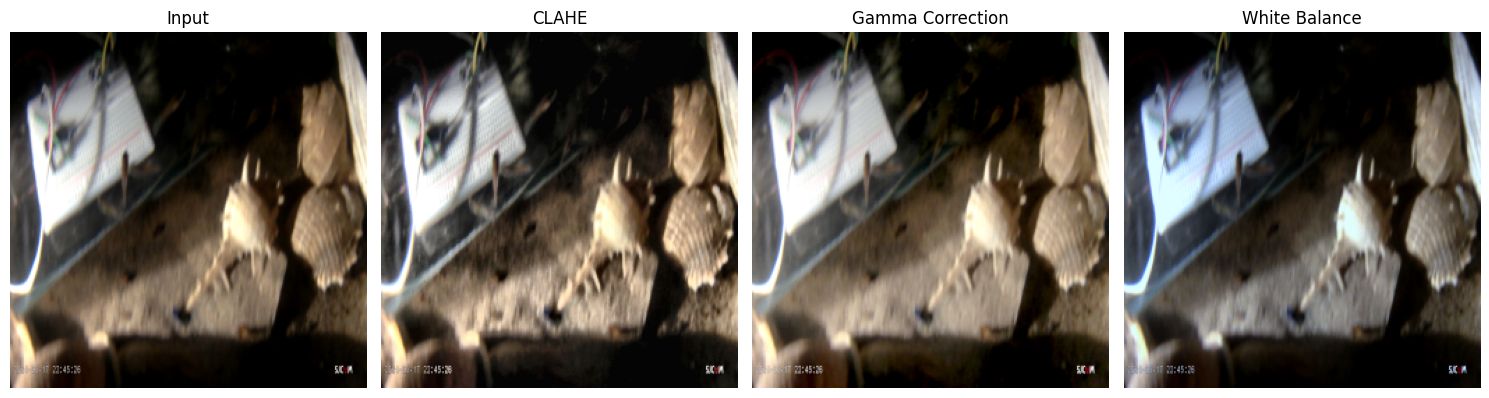

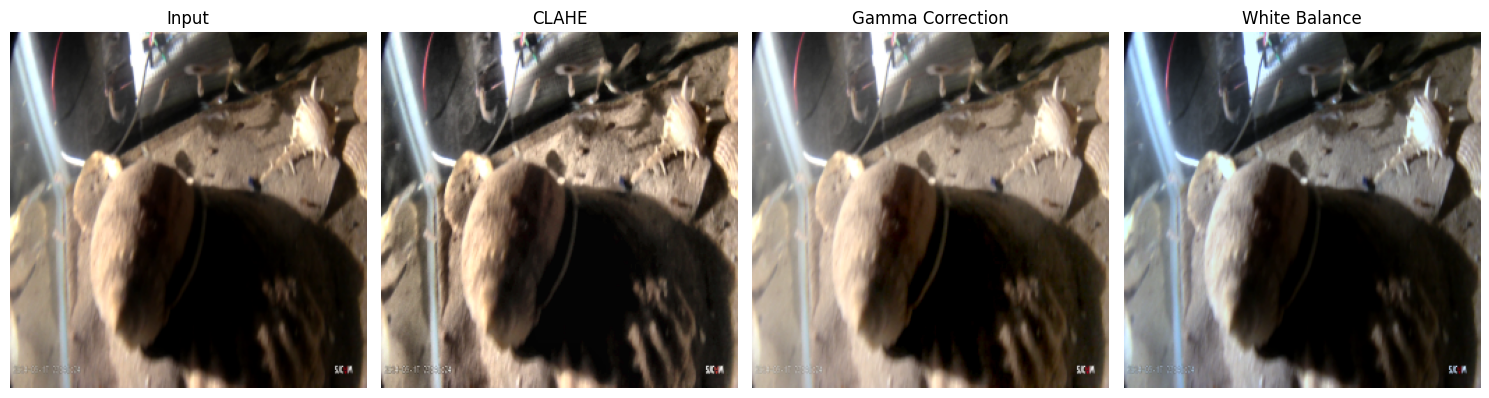

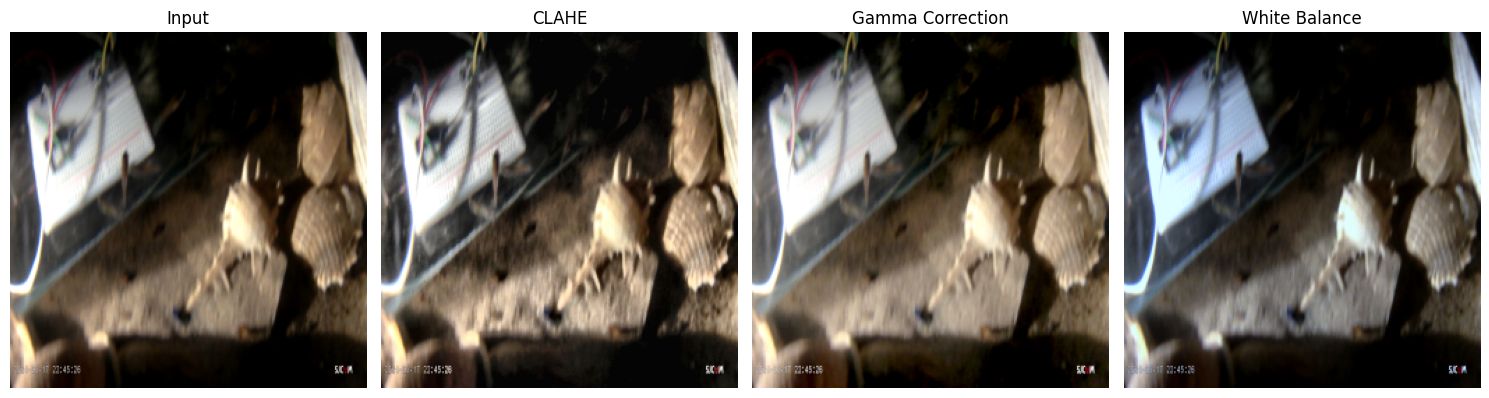

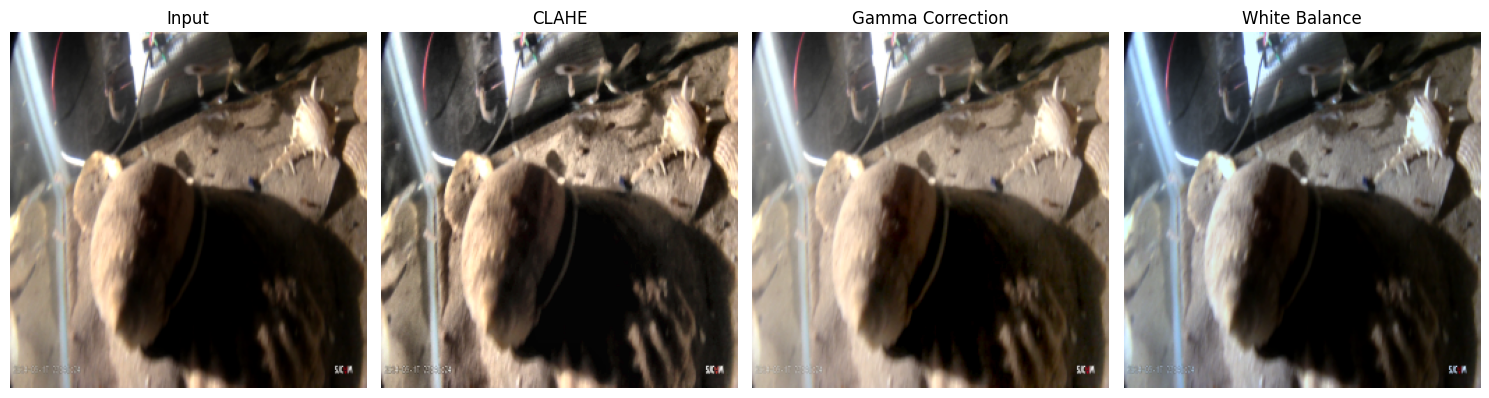

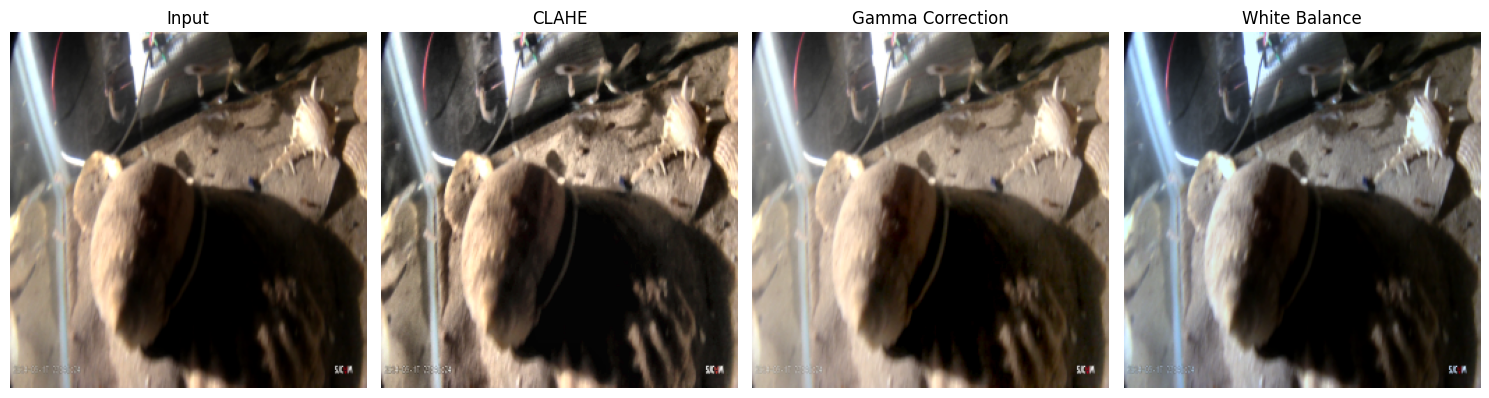

In [ ]:
# DAY 13 - CELL 6
# Visual comparison of classical methods

for input_path, target_path in sample_pairs:

    input_image = np.array(
        Image.open(input_path).convert("RGB")
    )

    target_image = np.array(
        Image.open(target_path).convert("RGB")
    )

    clahe_image = apply_clahe(input_image)
    gamma_image = apply_gamma(input_image)
    white_balance_image = apply_white_balance(input_image)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(input_image)
    plt.axis("off")
    plt.title("Input")

    plt.subplot(1, 4, 2)
    plt.imshow(clahe_image)
    plt.axis("off")
    plt.title("CLAHE")

    plt.subplot(1, 4, 3)
    plt.imshow(gamma_image)
    plt.axis("off")
    plt.title("Gamma Correction")

    plt.subplot(1, 4, 4)
    plt.imshow(white_balance_image)
    plt.axis("off")
    plt.title("White Balance")

    plt.tight_layout()
    plt.show()

Metrics calculated for all Input-Target pairs.
